In [1]:
import sys
from functools import partial
sys.path.append('../')
from math import log, comb, cos, sin
from numpy.linalg import matrix_power
from spd.OperatorSequence import *
from spd.SparsePauliDynamics import *
from spd.LightPauliDynamics import *
from pauli import *
from quantity import * 
from quantum_simulation_recipe.spin import Nearest_Neighbour_1d
from quantum_simulation_recipe.trotter import pf, expH
from qiskit.quantum_info import SparsePauliOp, random_statevector, Statevector
import matplotlib.pyplot as plt
from quantum_simulation_recipe.plot_config import *
set_fontsize(linewidth=2)
fig_dir, data_dir = './figs', './data'

In [3]:
import numpy as np
from itertools import product
import jax
import jax.numpy as jnp

def apply_pauli_string_jax(state_vector, pauli_indices):
    """
    Apply a Pauli string to the state vector using JAX.
    
    Args:
        state_vector: jax array of shape (2^n,)
        pauli_indices: array of integers [0,1,2,3] for [I,X,Y,Z]
    
    Returns:
        transformed state P|ψ⟩
    """
    n = len(pauli_indices)
    result = state_vector
    indices = jnp.arange(2**n)
    
    for qubit_idx in range(n):
        pauli_idx = pauli_indices[qubit_idx]
        bit_pos = n - 1 - qubit_idx
        
        # Skip identity
        def identity_op(r, idx):
            return r
        
        # X operator: flip bit
        def x_op(r, idx):
            new_indices = idx ^ (1 << bit_pos)
            return r[new_indices]
        
        # Y operator: Y|0⟩ = i|1⟩, Y|1⟩ = -i|0⟩
        def y_op(r, idx):
            bits = (idx >> bit_pos) & 1
            new_indices = idx ^ (1 << bit_pos)
            phase = jnp.where(bits == 0, 1j, -1j)
            return phase * r[new_indices]
        
        # Z operator: Z|0⟩ = |0⟩, Z|1⟩ = -|1⟩
        def z_op(r, idx):
            bits = (idx >> bit_pos) & 1
            phase = jnp.where(bits == 0, 1.0, -1.0)
            return phase * r
        
        # Apply the appropriate operator
        result = jax.lax.switch(
            pauli_idx,
            [identity_op, x_op, y_op, z_op],
            result,
            indices
        )
    
    return result


@jax.jit
def compute_expectation_single_jax(state_vector, pauli_indices):
    """
    Compute expectation value for a single Pauli string.
    JIT compiled for speed.
    """
    transformed = apply_pauli_string_jax(state_vector, pauli_indices)
    exp_val = jnp.vdot(state_vector, transformed)
    return jnp.real(exp_val)


@jax.jit
def compute_expectation_batch_jax(state_vector, pauli_indices_batch):
    """
    Compute expectation values for a batch of Pauli strings.
    JIT compiled and vectorized.
    """
    compute_all = jax.vmap(compute_expectation_single_jax, in_axes=(None, 0))
    return compute_all(state_vector, pauli_indices_batch)


def all_pauli_expectations_jax(state_vector, batch_size=None, show_progress=True):
    """
    Compute expectation values of all Pauli operators using JAX with batched processing.
    
    Args:
        state_vector: numpy array of shape (2^n,)
        batch_size: number of Paulis to process at once (auto-tuned if None)
        show_progress: whether to show tqdm progress bar
    
    Returns:
        Dictionary mapping Pauli strings to expectation values
    """
    try:
        from tqdm import tqdm
        has_tqdm = True
    except ImportError:
        has_tqdm = False
        if show_progress:
            print("Warning: tqdm not installed. Install with: pip install tqdm")
    
    n = int(np.log2(len(state_vector)))
    total_paulis = 4**n
    
    # Auto-tune batch size based on system memory and qubit count
    if batch_size is None:
        # Heuristic: keep intermediate arrays under ~500MB
        state_size = len(state_vector) * 16  # 16 bytes per complex number
        # batch_size * state_size should be < 500MB
        max_batch_memory = 500 * 1024 * 1024  # 500 MB
        batch_size = max(1, min(total_paulis, max_batch_memory // state_size))
        # Round to power of 4 for efficiency
        batch_size = min(batch_size, 16384)  # Cap at 16K for reasonable iteration
        print(f"Auto-selected batch size: {batch_size} (total: {total_paulis} Paulis)")
    
    # Convert to JAX array
    state_jax = jnp.array(state_vector)
    
    # Generate all Pauli strings as indices [0,1,2,3] for [I,X,Y,Z]
    pauli_to_idx = {'I': 0, 'X': 1, 'Y': 2, 'Z': 3}
    all_paulis = list(product(['I', 'X', 'Y', 'Z'], repeat=n))
    pauli_strings = [''.join(p) for p in all_paulis]
    
    # Process in batches
    all_exp_values = []
    num_batches = (total_paulis + batch_size - 1) // batch_size
    
    # Create progress bar
    iterator = range(num_batches)
    if show_progress and has_tqdm:
        iterator = tqdm(iterator, desc=f"Computing {total_paulis} Paulis", 
                       unit="batch", ncols=100)
    
    for batch_idx in iterator:
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, total_paulis)
        
        # Create batch of Pauli indices
        batch_paulis = all_paulis[start_idx:end_idx]
        pauli_indices_batch = jnp.array([[pauli_to_idx[c] for c in p] for p in batch_paulis])
        
        # Compute expectations for this batch
        batch_exp_values = compute_expectation_batch_jax(state_jax, pauli_indices_batch)
        all_exp_values.append(np.array(batch_exp_values))
    
    # Concatenate all results
    exp_values_np = np.concatenate(all_exp_values)
    expectations = {pauli: exp_val for pauli, exp_val in zip(pauli_strings, exp_values_np)}
    
    return expectations


def state_magic(state, batch_size=None, show_progress=True):
    """
    Compute the magic measure M_2^lin(ψ) = 1 - P_2
    where P_2 is the stabilizer purity.
    Uses JAX with batched processing for memory efficiency.
    
    Args:
        state: Qiskit Statevector object or numpy array
        batch_size: number of Paulis to process at once (auto-tuned if None)
        show_progress: whether to show tqdm progress bar
    
    Returns:
        magic: The magic measure M_2^lin(ψ)
    """
    # Get the state vector as numpy array
    if hasattr(state, 'data'):
        state_vector = state.data
    else:
        state_vector = state
    
    d = len(state_vector)  # d = 2^n
    
    # Compute all Pauli expectation values using JAX with batching
    expectations = all_pauli_expectations_jax(state_vector, batch_size, show_progress)
    
    # Extract expectation values and compute stabilizer purity P_2
    # P_2 = (1/d) * sum_P |<ψ|P|ψ>|^4
    exp_values = np.array(list(expectations.values()))
    
    P_2 = np.sum(np.abs(exp_values)**4) / d
    
    # Magic measure: M_2^lin(ψ) = 1 - P_2
    magic = 1 - P_2
    
    return magic

from qiskit.quantum_info import Pauli
from itertools import product
from tqdm import tqdm
def state_linear_magic(state):
    d = len(state)
    m = []
    pauligroup = [''.join(ops) for ops in product(['I','X','Y','Z'], repeat=int(np.log2(d)))]
    for j, paulistr in tqdm(enumerate(pauligroup), total=len(pauligroup), desc="Computing Paulis"):
        a = state.evolve(Pauli(paulistr))
        m1 = state.inner(a)
        m1 = np.sqrt(np.real(np.conj(m1)*m1))
        m.append(m1)
    magica = 1-d*np.average(np.power(m,4))
    return magica   

# Example usage with Qiskit
if __name__ == "__main__":
    from qiskit.quantum_info import Statevector
    from qiskit import QuantumCircuit
    import time
    
    print(f"JAX devices available: {jax.devices()}")
    print(f"Using device: {jax.devices()[0].device_kind}\n")
    
    # Test with product state |00⟩
    print("=== Product state |00⟩ ===")
    state_product = Statevector([1, 0, 0, 0])
    magic_val = state_magic(state_product)
    print(f"Magic measure: {magic_val:.6f}")
    
    # Bell state
    print("\n=== Bell state (|00⟩+|11⟩)/√2 ===")
    state = Statevector([1/np.sqrt(2), 0, 0, 1/np.sqrt(2)])
    magic_val = state_magic(state)
    print(f"Magic measure: {magic_val:.6f}")
    
    # T state (magic state): |T⟩ = (|0⟩ + e^(iπ/4)|1⟩)/√2
    print("\n=== T state (magic state) ===")
    qc = QuantumCircuit(1)
    qc.h(0)  # Hadamard
    qc.t(0)  # T gate
    state_t = Statevector.from_instruction(qc)
    print(f"State vector: {state_t.data}")
    magic_val = state_magic(state_t)
    print(f"Magic measure: {magic_val:.6f}")
    
    # Also test |+⟩ state (should have zero magic - it's stabilizer)
    print("\n=== |+⟩ state (Hadamard on |0⟩) ===")
    qc_plus = QuantumCircuit(1)
    qc_plus.h(0)
    state_plus = Statevector.from_instruction(qc_plus)
    magic_val = state_magic(state_plus)
    print(f"Magic measure: {magic_val:.6f}")
    
    print("\n=== Haar random state ===")
    from qiskit.quantum_info import random_statevector
    rand_sv = random_statevector(2**10)
    # rand_sv
    print('jax', state_magic(rand_sv, batch_size=4096*4, show_progress=True))
    print('qiskit', state_linear_magic(rand_sv))

JAX devices available: [CpuDevice(id=0)]
Using device: cpu

=== Product state |00⟩ ===
Auto-selected batch size: 16 (total: 16 Paulis)


Computing 16 Paulis: 100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 21.70batch/s]


Magic measure: 0.000000

=== Bell state (|00⟩+|11⟩)/√2 ===
Auto-selected batch size: 16 (total: 16 Paulis)


Computing 16 Paulis: 100%|███████████████████████████████████████| 1/1 [00:00<00:00, 2418.86batch/s]


Magic measure: 0.000000

=== T state (magic state) ===
State vector: [0.70710678+0.j  0.5       +0.5j]
Auto-selected batch size: 4 (total: 4 Paulis)


...

Magic measure: 0.000000

=== Haar random state ===



Computing 1048576 Paulis: 100%|██████████████████████████████████| 64/64 [00:31<00:00,  2.04batch/s]


jax 0.9961051589343697


Computing Paulis:   7%|▋         | 72030/1048576 [01:55<25:59, 626.17it/s]  


KeyboardInterrupt: 

In [15]:
from qiskit.quantum_info import random_statevector
rand_sv = random_statevector(2**9)
# rand_sv
print(state_magic(rand_sv))
print(state_linear_magic(rand_sv))

0.9922006875276566
0.9922006873599929


In [3]:
import numpy as np

def all_pauli_expectations(state_vector):
    """
    Compute expectation values of all Pauli operators.
    
    Args:
        state_vector: numpy array of shape (2^n,)
    
    Returns:
        Dictionary mapping Pauli strings to expectation values
    """
    n = int(np.log2(len(state_vector)))
    
    # Initialize with the state vector
    # We'll maintain arrays for each Pauli string prefix
    current = {(): state_vector.copy()}
    
    # Process each qubit
    for qubit in range(n):
        next_level = {}
        block_size = 2**(n - qubit - 1)
        
        for prefix, vec in current.items():
            # Reshape to separate this qubit's contribution
            vec_reshaped = vec.reshape(2, -1)
            v0, v1 = vec_reshaped[0], vec_reshaped[1]
            
            # Compute action of I, X, Y, Z on this qubit
            next_level[prefix + ('I',)] = np.concatenate([v0, v1])
            next_level[prefix + ('X',)] = np.concatenate([v1, v0])
            next_level[prefix + ('Y',)] = np.concatenate([1j*v1, -1j*v0])
            next_level[prefix + ('Z',)] = np.concatenate([v0, -v1])
        
        current = next_level
    
    # Compute expectation values
    expectations = {}
    for pauli_tuple, transformed_state in current.items():
        pauli_string = ''.join(pauli_tuple)
        expectations[pauli_string] = np.real(
            np.vdot(state_vector, transformed_state)
        )
    
    return expectations

In [7]:
all_pauli_expectations(Statevector.from_label('0'*10).data)

{'IIIIIIIIII': 1.0,
 'IIIIIIIIIX': 0.0,
 'IIIIIIIIIY': 0.0,
 'IIIIIIIIIZ': 1.0,
 'IIIIIIIIXI': 0.0,
 'IIIIIIIIXX': 1.0,
 'IIIIIIIIXY': 0.0,
 'IIIIIIIIXZ': 0.0,
 'IIIIIIIIYI': 0.0,
 'IIIIIIIIYX': 0.0,
 'IIIIIIIIYY': 1.0,
 'IIIIIIIIYZ': 0.0,
 'IIIIIIIIZI': 1.0,
 'IIIIIIIIZX': 0.0,
 'IIIIIIIIZY': 0.0,
 'IIIIIIIIZZ': 1.0,
 'IIIIIIIXII': 0.0,
 'IIIIIIIXIX': 1.0,
 'IIIIIIIXIY': 0.0,
 'IIIIIIIXIZ': 0.0,
 'IIIIIIIXXI': 1.0,
 'IIIIIIIXXX': 0.0,
 'IIIIIIIXXY': 0.0,
 'IIIIIIIXXZ': 1.0,
 'IIIIIIIXYI': 0.0,
 'IIIIIIIXYX': 0.0,
 'IIIIIIIXYY': 0.0,
 'IIIIIIIXYZ': 0.0,
 'IIIIIIIXZI': 0.0,
 'IIIIIIIXZX': -1.0,
 'IIIIIIIXZY': 0.0,
 'IIIIIIIXZZ': 0.0,
 'IIIIIIIYII': 0.0,
 'IIIIIIIYIX': 0.0,
 'IIIIIIIYIY': 1.0,
 'IIIIIIIYIZ': 0.0,
 'IIIIIIIYXI': 0.0,
 'IIIIIIIYXX': 0.0,
 'IIIIIIIYXY': 0.0,
 'IIIIIIIYXZ': 0.0,
 'IIIIIIIYYI': 1.0,
 'IIIIIIIYYX': 0.0,
 'IIIIIIIYYY': 0.0,
 'IIIIIIIYYZ': 1.0,
 'IIIIIIIYZI': 0.0,
 'IIIIIIIYZX': 0.0,
 'IIIIIIIYZY': -1.0,
 'IIIIIIIYZZ': 0.0,
 'IIIIIIIZII': 1.0,
 'IIIIIIIZIX': 0.0

In [1]:
import jax
import jax.numpy as jnp
from itertools import product
import numpy as np

# Precompute Pauli matrices
I = jnp.array([[1, 0], [0, 1]], dtype=jnp.complex64)
X = jnp.array([[0, 1], [1, 0]], dtype=jnp.complex64)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=jnp.complex64)
Z = jnp.array([[1, 0], [0, -1]], dtype=jnp.complex64)

pauli_dict = {'I': I, 'X': X, 'Y': Y, 'Z': Z}

def build_pauli_matrix(pauli_str):
    """Build full Pauli operator from string like 'XYZ'"""
    result = pauli_dict[pauli_str[0]]
    for p in pauli_str[1:]:
        result = jnp.kron(result, pauli_dict[p])
    return result

@jax.jit
def compute_magic_vectorized(state_vec, pauli_matrices):
    """Vectorized computation of magic measure"""
    # state_vec: (d,) complex array
    # pauli_matrices: (num_paulis, d, d) complex array
    
    # Batch matrix-vector multiplication: (num_paulis, d, d) @ (d,) -> (num_paulis, d)
    evolved_states = jnp.einsum('ijk,k->ij', pauli_matrices, state_vec)
    
    # Compute inner products: (num_paulis,)
    inner_prods = jnp.einsum('i,ij->j', jnp.conj(state_vec), evolved_states)
    
    # Compute magnitudes
    m = jnp.abs(inner_prods)
    
    # Compute magic
    d = len(state_vec)
    magica = 1 - d * jnp.mean(m**4)
    
    return magica

def state_magic_jax(state):
    """
    Fast GPU-accelerated magic computation
    
    Args:
        state: Qiskit Statevector or numpy array
    """
    # Convert to JAX array
    if hasattr(state, 'data'):
        state_vec = jnp.array(state.data, dtype=jnp.complex64)
    else:
        state_vec = jnp.array(state, dtype=jnp.complex64)
    
    d = len(state_vec)
    n_qubits = int(np.log2(d))
    
    # Build all Pauli matrices once
    pauligroup = [''.join(ops) for ops in product(['I','X','Y','Z'], repeat=n_qubits)]
    pauli_matrices = jnp.array([build_pauli_matrix(p) for p in pauligroup], 
                               dtype=jnp.complex64)
    
    # Compute magic
    return compute_magic_vectorized(state_vec, pauli_matrices)


In [3]:
state_magic_jax(Statevector.from_label('0'*8))

: 

In [2]:
n = 10 # 10
t = 10  
r = 50 # 100

dt = t/r
# H_model = 'MFI'
# hx, hy, Jx = 1, 0.9, 0.8
Jx, hx, hy = 1, 0.8, 0.9
print(f't={t}, r={r}, dt={dt}')

# init_state_str = '0'*n
init_state_str = '10'*(n//2)
init_state = Statevector.from_label(init_state_str).data

z1 = SparsePauliOp('I'*(n-1)+'Z', 1)
ob_op = z1
obs = ob_op.to_matrix()
complete_fnorm = 2**(-n/2)*np.linalg.norm(obs, ord='fro')

t=10, r=50, dt=0.2


In [3]:
## QMFI
qmfi = Nearest_Neighbour_1d(n, hx=hx, hy=hy, Jx=Jx, pbc=False)
qmfi_xx_even = SparsePauliOp.from_sparse_list([*qmfi.xx_tuples[::2]], num_qubits=n).simplify()
qmfi_xx_odd = SparsePauliOp.from_sparse_list([*qmfi.xx_tuples[1::2]], num_qubits=n).simplify()
qmfi_x_terms = SparsePauliOp.from_sparse_list([*qmfi.x_tuples], num_qubits=n).simplify()
qmfi_y_terms = qmfi.y_terms
qmfi_H_list = [qmfi_x_terms, qmfi_y_terms, qmfi_xx_even, qmfi_xx_odd] 
qmfi_H_ordered = sum(qmfi_H_list)
qmfi_U_dt_ideal = expH(sum(qmfi_H_ordered), dt, use_jax=False)
qmfi_U_dt_appro = pf(qmfi_H_ordered, dt, 1, 1)

qmfi_ideal_ops = [matrix_power(qmfi_U_dt_ideal, i) for i in range(r+1)]
qmfi_trott_ops = [matrix_power(qmfi_U_dt_appro, i) for i in range(r+1)]

print('evoluate states...')
qmfi_ideal_states = [qmfi_ideal_ops[i]@init_state for i in range(r+1)]
qmfi_trott_states = [qmfi_trott_ops[i]@init_state for i in range(r+1)]
print('evoluate obs...')
qmfi_trott_obs = [op.conjugate().transpose() @ obs @ op for op in qmfi_trott_ops]
qmfi_ideal_obs = [op.conjugate().transpose() @ obs @ op for op in qmfi_ideal_ops]
print('evoluate expvals...')
qmfi_ideal_expvals = [expect_value(obs, qmfi_ideal_states[i]) for i in range(r+1)]
qmfi_trott_expvals = [expect_value(obs, qmfi_trott_states[i]) for i in range(r+1)]

qmfi_ops = dt*sum(qmfi_H_list)
# print('ops:', ops)
# print('obs:', obs)

evoluate states...
evoluate obs...
evoluate expvals...


In [4]:
## QTFI
qtfi = Nearest_Neighbour_1d(n, hy=hy, Jx=Jx, pbc=False)
qtfi_xx_even = SparsePauliOp.from_sparse_list([*qtfi.xx_tuples[::2]], num_qubits=n).simplify()
qtfi_xx_odd = SparsePauliOp.from_sparse_list([*qtfi.xx_tuples[1::2]], num_qubits=n).simplify()
qtfi_x_terms = SparsePauliOp.from_sparse_list([*qtfi.x_tuples], num_qubits=n).simplify()
qtfi_y_terms = qtfi.y_terms
qtfi_H_list = [qtfi_x_terms, qtfi_y_terms, qtfi_xx_even, qtfi_xx_odd] 
qtfi_H_ordered = sum(qtfi_H_list)
qtfi_U_dt_ideal = expH(sum(qtfi_H_ordered), dt, use_jax=False)
qtfi_U_dt_appro = pf(qtfi_H_ordered, dt, 1, 1)

qtfi_ideal_ops = [matrix_power(qtfi_U_dt_ideal, i) for i in range(r+1)]
qtfi_trott_ops = [matrix_power(qtfi_U_dt_appro, i) for i in range(r+1)]

print('evoluate states...')
qtfi_ideal_states = [qtfi_ideal_ops[i]@init_state for i in range(r+1)]
qtfi_trott_states = [qtfi_trott_ops[i]@init_state for i in range(r+1)]
print('evoluate obs...')
qtfi_trott_obs = [op.conjugate().transpose() @ obs @ op for op in qtfi_trott_ops]
qtfi_ideal_obs = [op.conjugate().transpose() @ obs @ op for op in qtfi_ideal_ops]
print('evoluate expvals...')
qtfi_ideal_expvals = [expect_value(obs, qtfi_ideal_states[i]) for i in range(r+1)]
qtfi_trott_expvals = [expect_value(obs, qtfi_trott_states[i]) for i in range(r+1)]

qtfi_ops = dt*sum(qtfi_H_list)
# print('ops:', ops)
# print('obs:', obs)

evoluate states...
evoluate obs...
evoluate expvals...


In [5]:
exp_val_func = partial(exp_val_0101_state_pauli_rep, n_qubits=n)
# exp_val_func = exp_val_all_zeros_pauli_rep

w_thres = n
qmfi_sim = LowWeightPauliPropagation.from_pauli_list(ob_op, qmfi_ops, threshold=w_thres, nprocs=4)
qmfi_res = qmfi_sim.run_dynamics(r, process=exp_val_func, process_every=1, verbose=False)
qmfi_res = np.array(qmfi_res)
# res = res / res[0].sum()

qtfi_sim = LowWeightPauliPropagation.from_pauli_list(ob_op, qtfi_ops, threshold=w_thres+1, nprocs=4)
qtfi_res = qtfi_sim.run_dynamics(r, process=exp_val_func, process_every=1, verbose=False)
qtfi_res = np.array(qtfi_res)

qmfi_norm_weight_steps = [weight_2norm_distr(ob, n) for ob in qmfi_sim.evo_obs]
qtfi_norm_weight_steps = [weight_2norm_distr(ob, n) for ob in qtfi_sim.evo_obs]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
100%|██████████| 50/50 [00:00<00:00, 168.53it/s]


In [6]:
sub_dim = 3
qmfi_entangle_entropy3 = [entangle_entropy(state, sub_dim) for state in qmfi_trott_states]
qtfi_entangle_entropy3 = [entangle_entropy(state, sub_dim) for state in qtfi_trott_states]
qmfi_magic = [operator_magic(obs) for obs in qmfi_sim.evo_obs]
qtfi_magic = [operator_magic(obs) for obs in qtfi_sim.evo_obs]

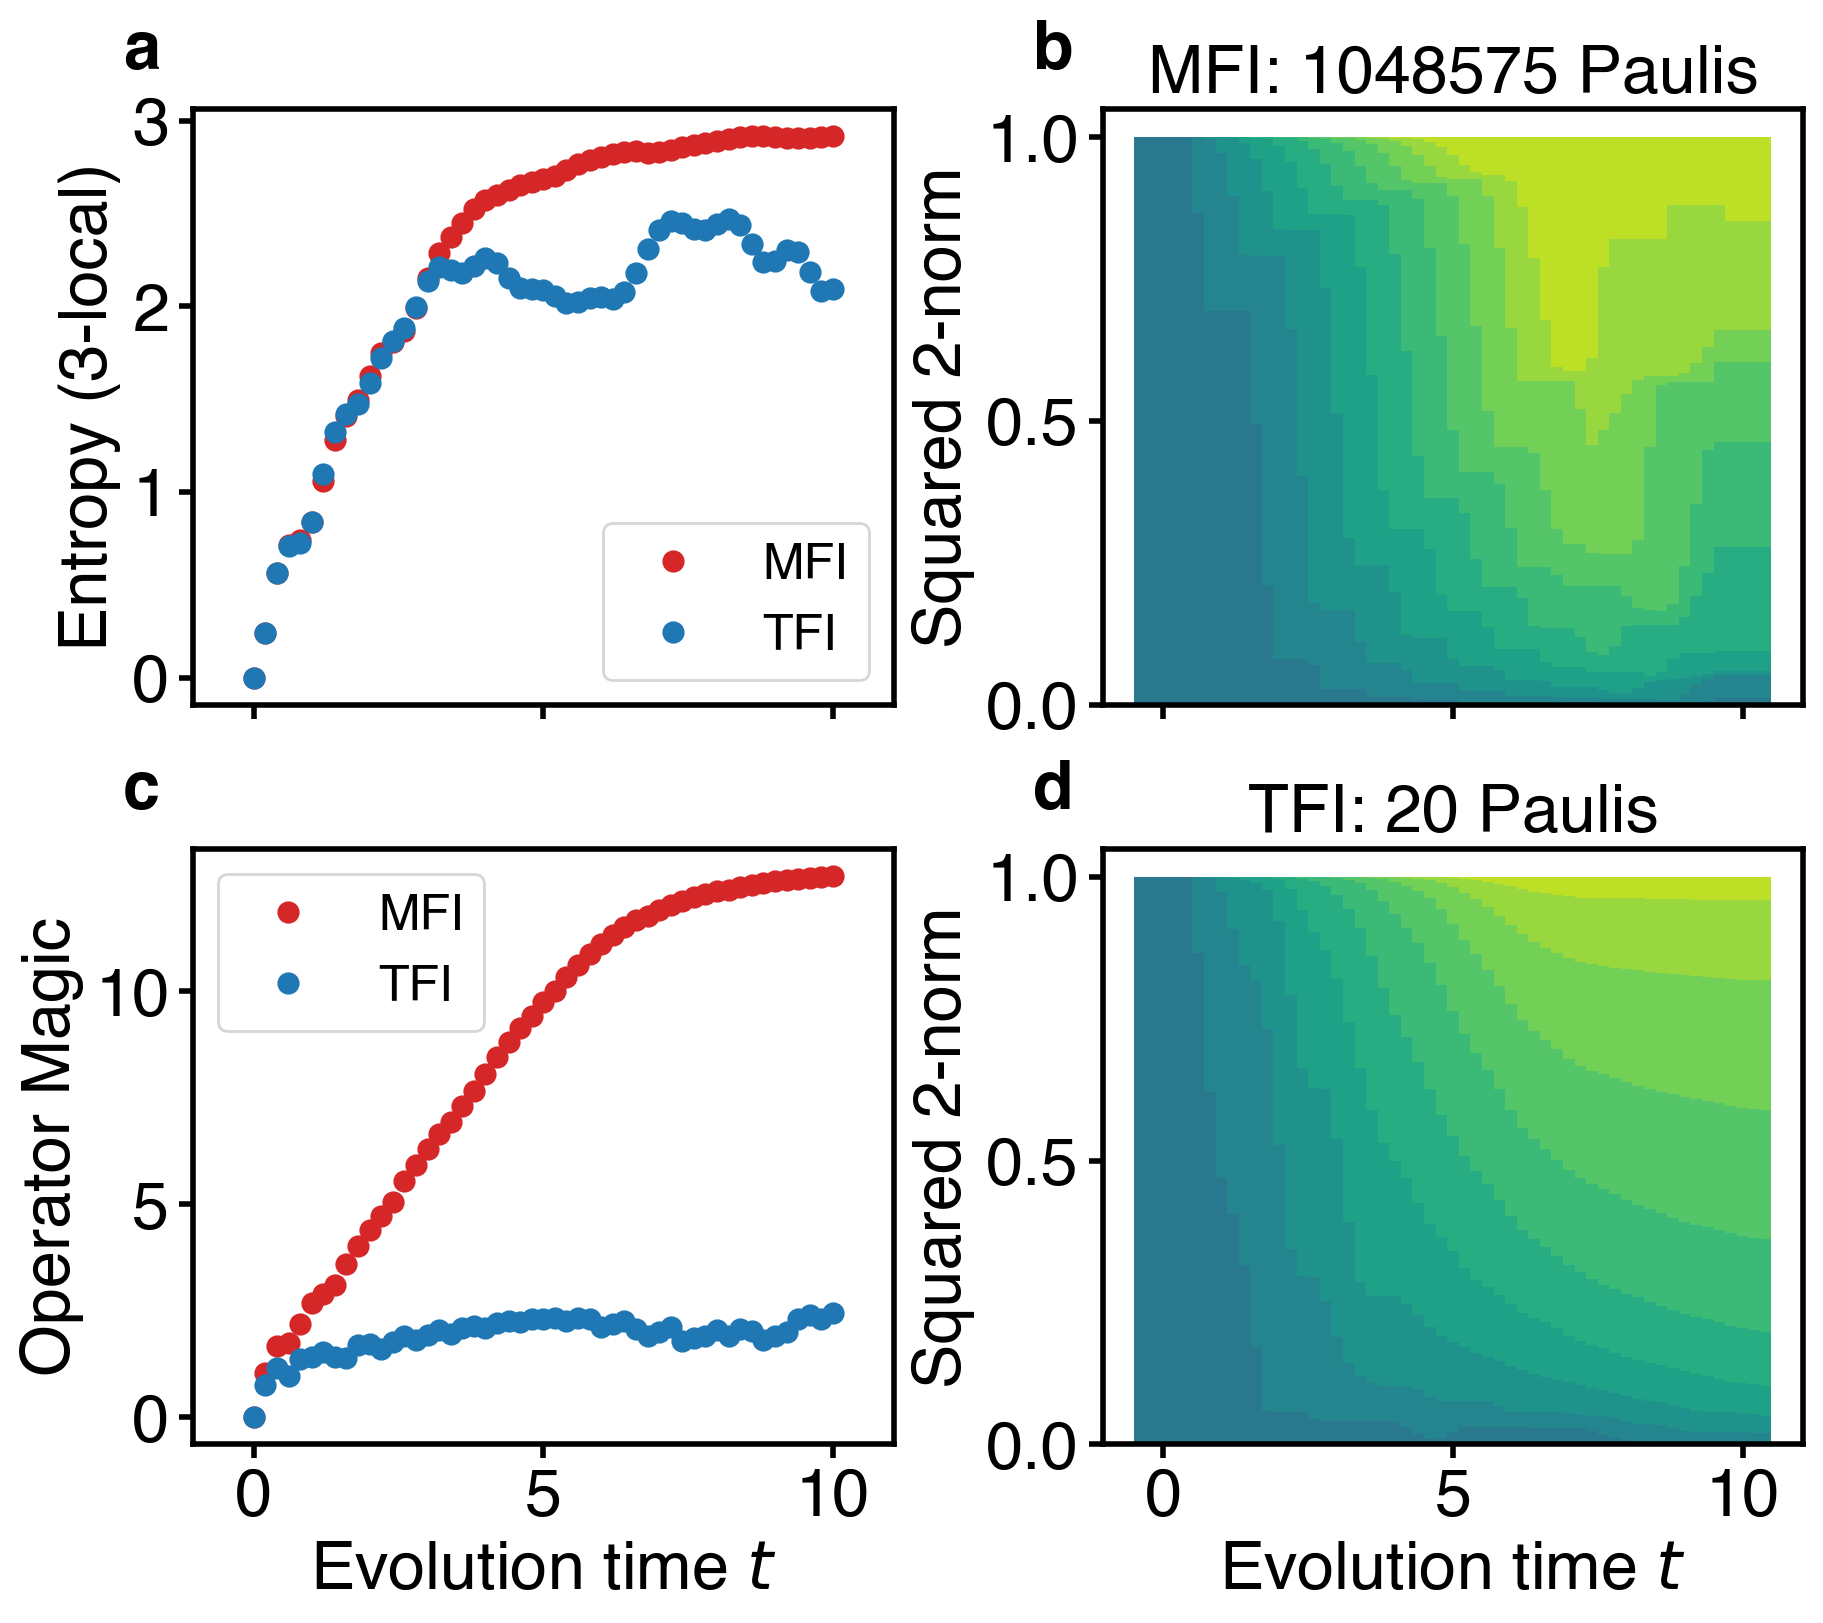

In [8]:
t_list = [i*dt for i in range(r+1)]
fig, axes = plt.subplots(2, 2, sharex=True, figsize=(9, 8), layout='constrained')
colors = plt.cm.viridis(np.linspace(0.4, 0.9, n))
for w in range(n, 0, -1):
    qmfi_norm2_distr = [sum(qmfi_norm_weight_steps[i][:w]) for i in range(len(t_list))]
    qtfi_norm2_distr = [sum(qtfi_norm_weight_steps[i][:w]) for i in range(len(t_list))]
    bars = axes[0,1].bar(t_list, qtfi_norm2_distr, 1, color=colors[w-1], label=f'w<={w}')
    bars = axes[1,1].bar(t_list, qmfi_norm2_distr, 1, color=colors[w-1], label=f'w<={w}')
axes[0,1].set_ylabel(r'Squared 2-norm'); 
axes[0,1].set_title(f'MFI: {qmfi_sim.evo_obs[-1].size()} Paulis') 
axes[1,1].set_title(f'TFI: {qtfi_sim.evo_obs[-1].size()} Paulis') 
axes[1,1].set_ylabel(r'Squared 2-norm') # axes[1,0].legend(loc='upper right')
axes[1,1].set_xlabel(rf'Evolution time $t$')

axes[0,0].plot(t_list, qmfi_entangle_entropy3, '.', label='MFI', c='tab:red')
axes[0,0].plot(t_list, qtfi_entangle_entropy3, '.', label='TFI', c='tab:blue')
axes[0,0].set_ylabel(f'Entropy ({sub_dim}-local)'); axes[0,0].legend()
axes[1,0].plot(t_list, qmfi_magic, '.', label='MFI', c='tab:red')
axes[1,0].plot(t_list, qtfi_magic, '.', label='TFI', c='tab:blue')
axes[1,0].set_ylabel('Operator Magic'); axes[1,0].legend()
axes[1,0].set_xlabel(rf'Evolution time $t$')

for ax, label in zip(axes.flatten(), ['a', 'b', 'c', 'd']): 
    ax.text(-0.10, 1.15, label, transform=ax.transAxes, fontsize=24, va='top', weight='bold')

fig.savefig(f'{fig_dir}/Magic_Entangle_n={n}_t={t}_r={r}.pdf', bbox_inches='tight')

In [28]:
evo_obs = [item.to_sparse_pauli_op(n) for item in sim1.evo_obs]
norm_weight_steps = []
for i, ob in enumerate(sim1.evo_obs):
    temp_step = []
    # print(i, norm_weight_steps)
    for w in range(1, n+1):
        ob_w = decompose_by_weight_pauli_rep(ob)
        # print(ob_w)
        if w in ob_w:
            temp_step.append(ob_w[w].p2norm()**2)
        else:
            # print(f'No weight {w} Paulis')
            temp_step.append(0)
    norm_weight_steps.append(temp_step)

pauli_diff_fnorm = [2**(-n/2)*np.linalg.norm(ob.to_matrix() - trott_obs[i], ord='fro')/complete_fnorm for i, ob in enumerate(evo_obs)]
print(pauli_diff_fnorm)
trott_diff_fnorm = [2**(-n/2)*np.linalg.norm(ob - trott_obs[i], ord='fro')/complete_fnorm for i, ob in enumerate(ideal_obs)]

n_states = 200
haar_states = [random_statevector(2**n) for _ in range(n_states)]
# Verify 2-design property using Haar random states
expvals_pauli_diff = [[abs(states.expectation_value(ob.to_matrix() - trott_obs[i])) for states in haar_states] for i, ob in enumerate(evo_obs)]
expvals_trott_diff = [[abs(states.expectation_value(ob - trott_obs[i])) for states in haar_states] for i, ob in enumerate(ideal_obs)]

[0.0, 1.1099614042939736e-15, 2.4310592870133338e-15, 3.211756068922338e-15, 3.625504831580959e-06, 2.7520867425055504e-05, 0.00011552900866601548, 0.00035190348078254646, 0.000863518122656585, 0.0018024504769196222, 0.00331242105204725, 0.0055044899999427245, 0.008489040035058647, 0.012509431919239462, 0.018152751143472343, 0.02645659459916393, 0.03868450896072565, 0.05583793946222428, 0.07822271357897453, 0.10526546243726866, 0.13563862330988802, 0.16770438377679917, 0.2001650657078882, 0.2326264365241849, 0.26569923461427625, 0.30046379923058736, 0.3376038197601632, 0.3768612071557347, 0.4171994150322768, 0.4574292167037512, 0.49674491029654466, 0.5348334422301222, 0.5716183058928728, 0.6069467012638904, 0.64049151092769, 0.671902488296779, 0.7010267218346371, 0.7279949568041231, 0.7531141078952582, 0.7766656429828658, 0.7987589425075882, 0.8193193098428143, 0.8381863201769878, 0.8552435378993393, 0.8705121994606081, 0.8841828045820721, 0.8965906643327135, 0.9081508089114099, 0.9192

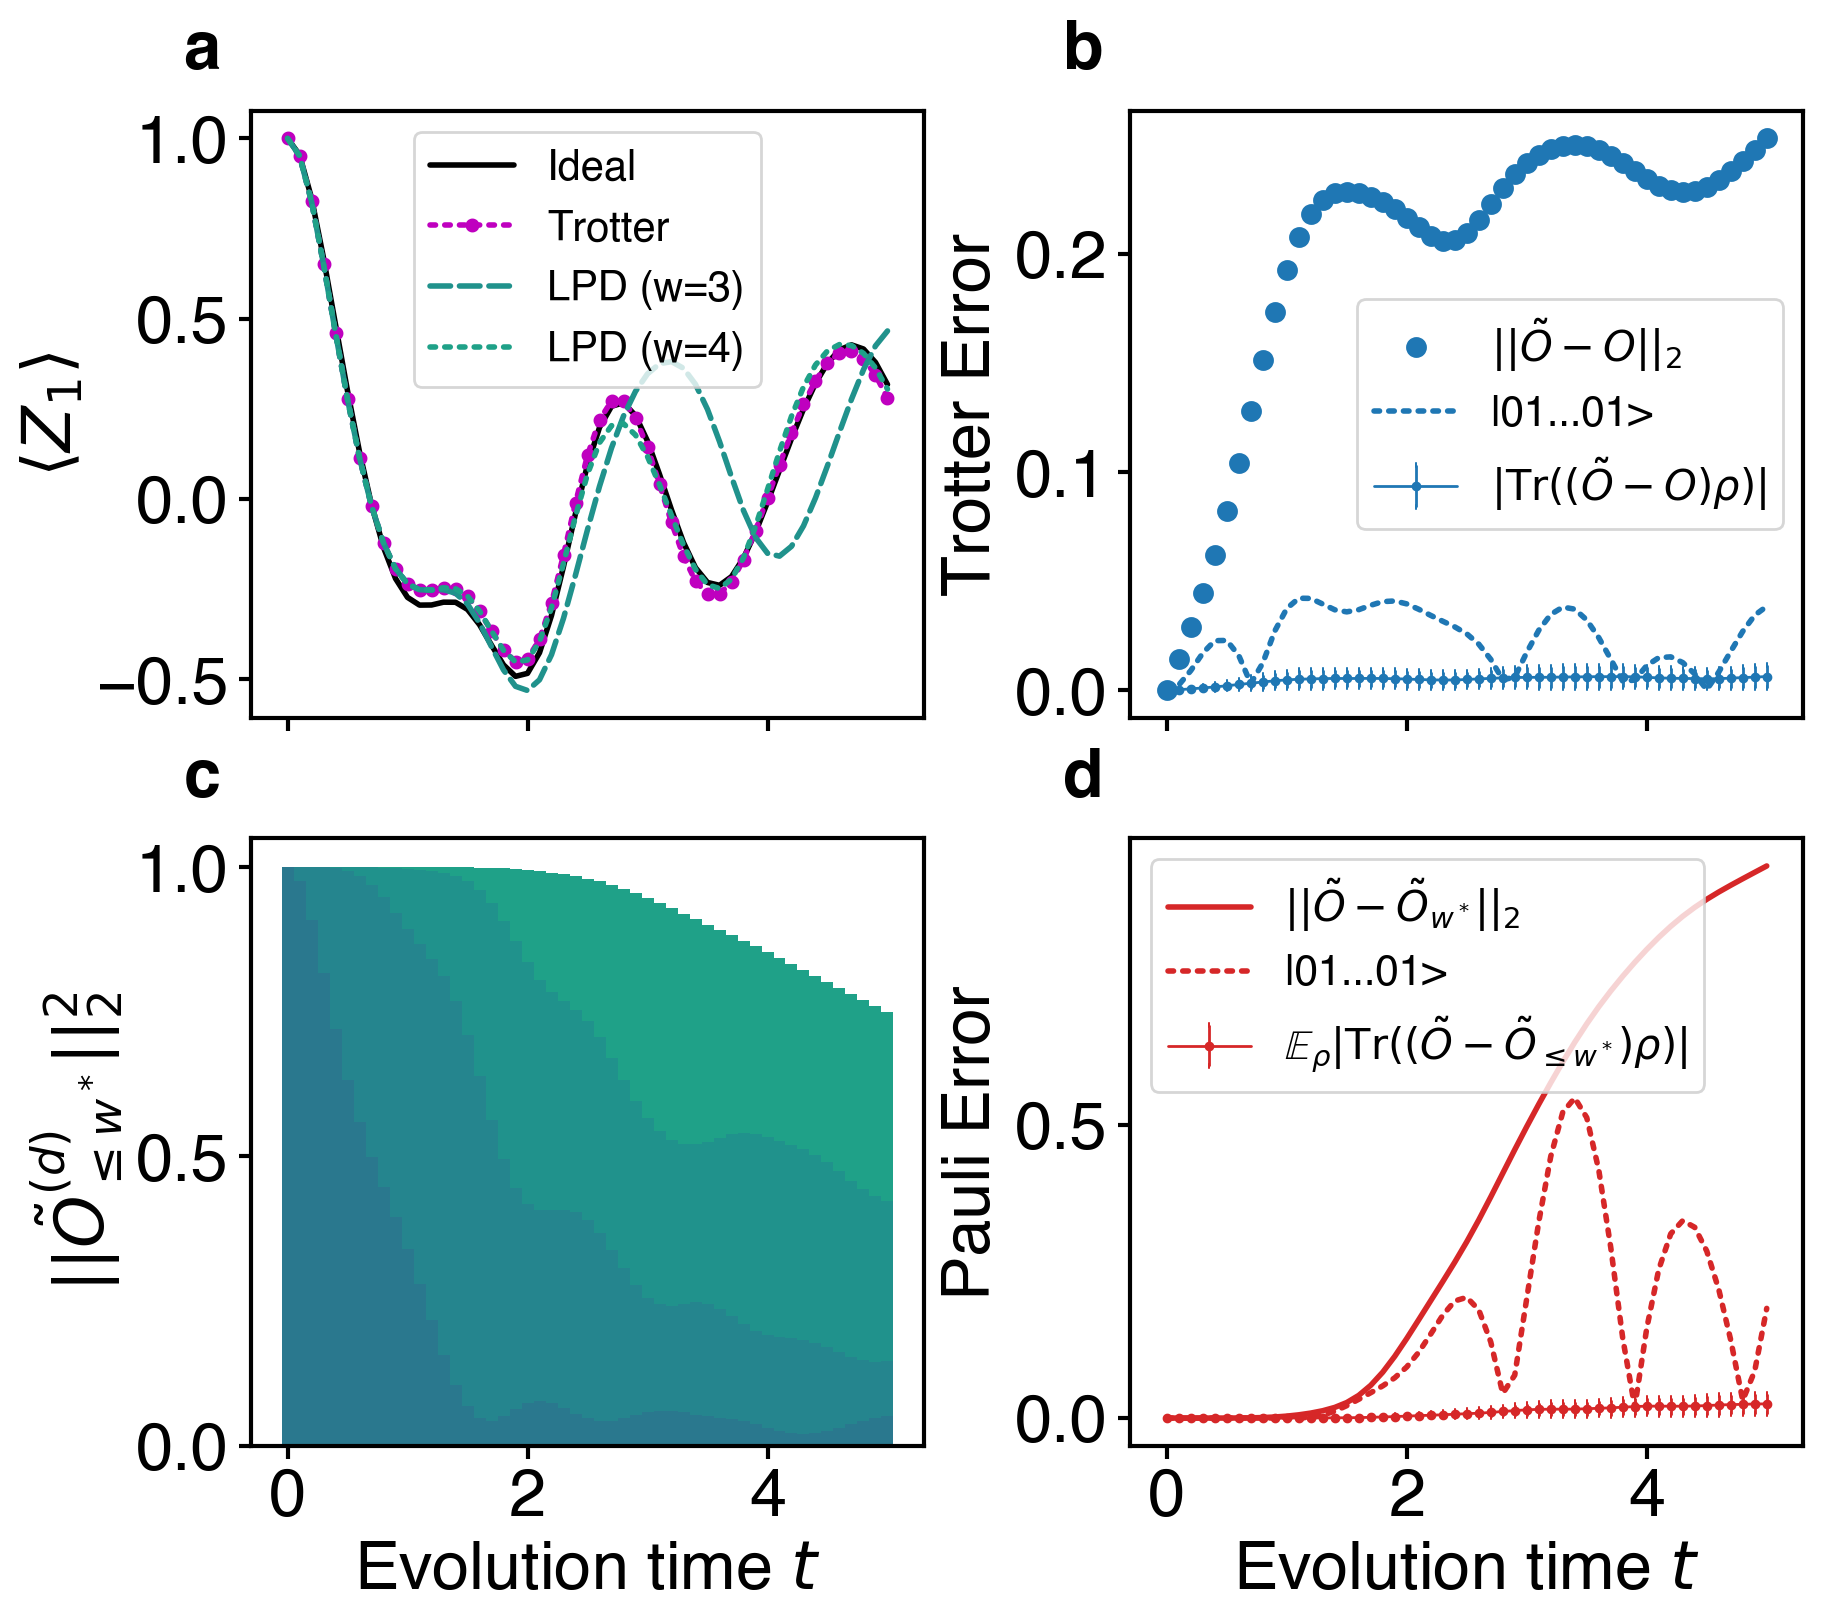

In [ ]:
t_dense_list = np.array(range(len(ideal_expvals))) * t/t_num_dense
t_list = np.array(range(len(trott_expvals))) * dt
colors = plt.cm.viridis(np.linspace(0.4, 0.9, n))
# colors = plt.cm.plasma(np.linspace(0.3, 0.9, n))

fig, axes = plt.subplots(2, 2, sharex=True, figsize=(9, 8), layout='constrained') # , layout='constrained'
axes[0,0].plot(t_dense_list, ideal_expvals, '-', label='Ideal', c='k')
axes[0,0].plot(t_list, trott_expvals, ':.', label='Trotter', c='m', ms=6)
axes[0,0].plot(t_list, res.real, '--', label=f'LPD (w*={w_thres})', c=colors[w_thres-1])
axes[0,0].plot(t_list, res1.real, ':', label=f'LPD (w*={w_thres+1})', c=colors[w_thres])
axes[1,0].set_xlabel(rf'Evolution time $t$'); 
axes[0,0].set_ylabel(rf'$\langle Z_1 \rangle$')
axes[0,0].legend(loc='upper center', fontsize='small', ncol=1)
# axes[0,0].set_title(rf'{H_model}, n={n}, t={t}, r={r}, init={init_state_str[:2]}')

axes[1,1].plot(t_list, pauli_diff_fnorm, '-', label=r'$||\tilde{O}-\tilde{O}_{ w^*}||_2$', c='tab:red')
axes[1,1].errorbar(t_list, np.array(expvals_pauli_diff).mean(axis=1), yerr=np.array(expvals_pauli_diff).std(axis=1), fmt='.-', label=r'$\mathbb{E}_{\rho}|\text{Tr}((\tilde{O}-\tilde{O}_{\leq w^*})\rho)|$', c='tab:red', capsize=0.5, lw=1, ms=3)
axes[1,1].plot(t_list, abs(trott_expvals-res), ':', label=f'|01...01>', c='tab:red')
axes[1,1].set_ylabel(rf'Pauli Error'); axes[1,1].legend(loc='upper left', fontsize='small')
axes[1,1].set_xlabel(rf'Evolution time $t$'); 
axes[0,1].plot(t_list, trott_diff_fnorm, '.', label=r'$||\tilde{O}-O||_2$', c='tab:blue')
axes[0,1].errorbar(t_list, np.array(expvals_trott_diff).mean(axis=1), yerr=np.array(expvals_trott_diff).std(axis=1), fmt='.-', label=r'$|\text{Tr}((\tilde{O}-O)\rho)|$', c='tab:blue', capsize=0.5, lw=1, ms=3)
axes[0,1].plot(t_list, abs(np.array(trott_expvals)-np.array(ideal_expvals)), ':', label=f'|01...01>', c='tab:blue')
axes[0,1].set_ylabel(rf'Trotter Error'); axes[0,1].legend(loc='center right', fontsize='small')


for ax, label in zip(axes.flatten(), ['a', 'b', 'c', 'd']): 
    ax.text(-0.10, 1.15, label, transform=ax.transAxes, fontsize=24, va='top', weight='bold')

fig.savefig(f'{fig_dir}/magic_entangle_n={n}_t={t}_r={r}_{init_state_str[:4]}.pdf', bbox_inches='tight')